## Import all required libraries

In [29]:
pip install matplotlib

  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 21.1 MB/s  0:00:00
Using cached pillow-12.1.1-cp314-cp314-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [31]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [32]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

Create dataframes of both training as well as testing data

In [34]:
with open("/Users/ssweeti/Desktop/Module2_project/usersessions/dataset.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)

with open("/Users/ssweeti/Desktop/Module2_project/usersessions/verify.json") as f:
    verify_data = json.load(f)

verify_df = pd.json_normalize(verify_data)

In [35]:
df.shape

(80000, 9)

In [36]:
verify_df.shape

(22700, 8)

In [37]:
df.head()

,browser,os,locale,user_id,gender,location,sites,time,date
0,Firefox,Ubuntu,ru_RU,105,m,USA/Chicago,"[{'site': 'mail.google.com', 'length': 50}, {'...",09:03:00,2017-01-08
1,Firefox,Windows 8,pl-PL,11,m,USA/Chicago,"[{'site': 'meduza.org', 'length': 40}, {'site'...",13:57:00,2016-10-05
2,Chrome,Ubuntu,zh-CN,17,m,Singapore/Singapore,"[{'site': 'facebook.net', 'length': 74}, {'sit...",02:06:00,2017-03-28
3,Chrome,Windows 10,pt-BR,134,f,Australia/Sydney,"[{'site': 'verisign.com', 'length': 111}, {'si...",21:49:00,2017-06-25
4,Firefox,Windows 10,en-SG,92,f,USA/Chicago,"[{'site': 'live.com', 'length': 79}, {'site': ...",00:05:00,2016-02-10


In [38]:
verify_df.head()

,browser,os,locale,gender,location,sites,time,date
0,Chrome,Ubuntu,ru_RU,m,Canada/Toronto,"[{'site': 'mail.google.com', 'length': 383}, {...",16:59:00,2017-09-05
1,Chrome,Ubuntu,ru_RU,m,Canada/Toronto,"[{'site': 'mail.google.com', 'length': 59}, {'...",16:42:00,2017-09-07
2,Firefox,Ubuntu,ru_RU,m,Canada/Toronto,"[{'site': 'mail.google.com', 'length': 50}, {'...",17:42:00,2017-09-09
3,Chrome,Windows 10,ru_RU,m,Canada/Toronto,"[{'site': 'mail.google.com', 'length': 153}, {...",01:29:00,2017-09-12
4,Firefox,Ubuntu,ru_RU,m,Canada/Toronto,"[{'site': 'mail.google.com', 'length': 40}, {'...",16:28:00,2017-09-13


verify data is not having user_id

# create target variable

In [39]:
df["target"] = (df["user_id"] == 0).astype(int)

In [40]:
df["target"].value_counts()

target
0    79600
1      400
Name: count, dtype: int64

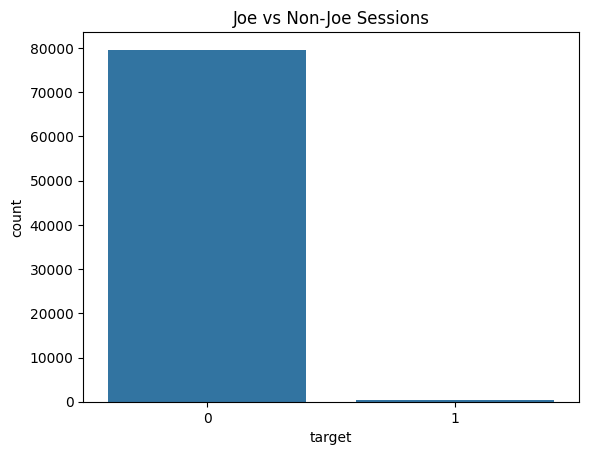

In [41]:
sns.countplot(x=df["target"])
plt.title("Joe vs Non-Joe Sessions")
plt.show()

In [42]:
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

/var/folders/n4/5mpnny3d2n5dqdtvgpbhfmdw0000gn/T/ipykernel_8294/681183122.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"])


In [43]:
df["date"] = pd.to_datetime(df["date"])
df["weekday"] = df["date"].dt.dayofweek

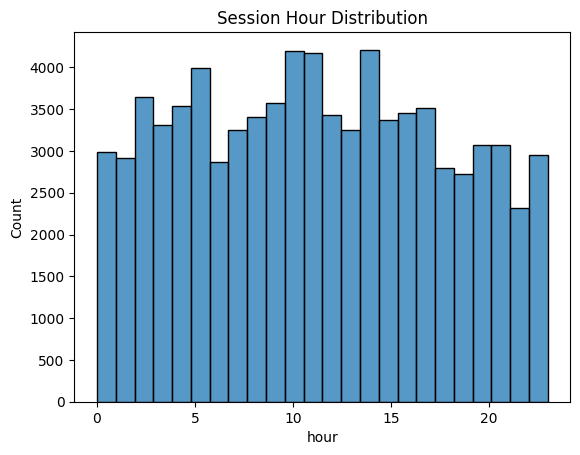

In [44]:
sns.histplot(df["hour"], bins=24)
plt.title("Session Hour Distribution")
plt.show()

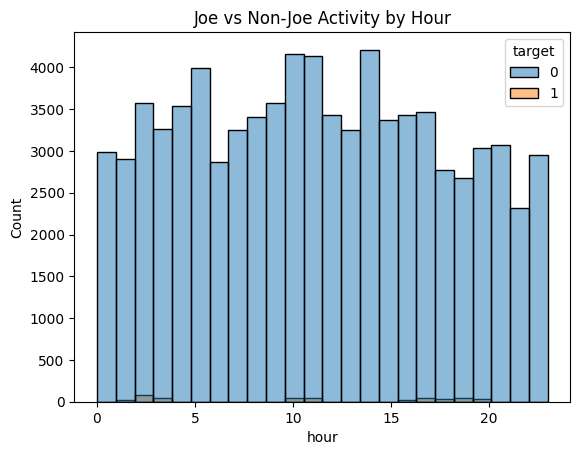

In [45]:
sns.histplot(data=df, x="hour", hue="target", bins=24)
plt.title("Joe vs Non-Joe Activity by Hour")
plt.show()

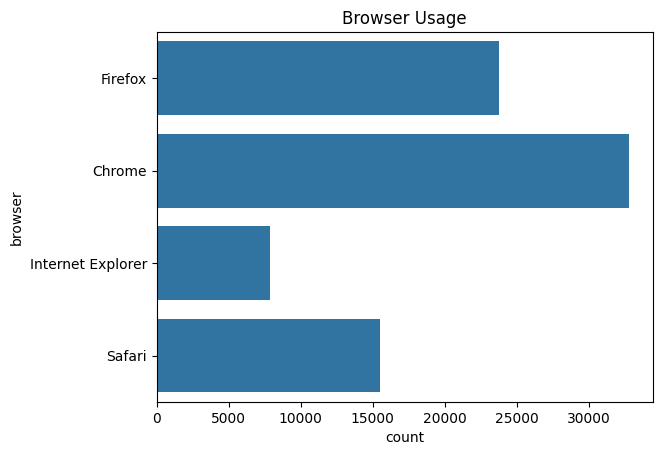

In [46]:
sns.countplot(y=df["browser"])
plt.title("Browser Usage")
plt.show()

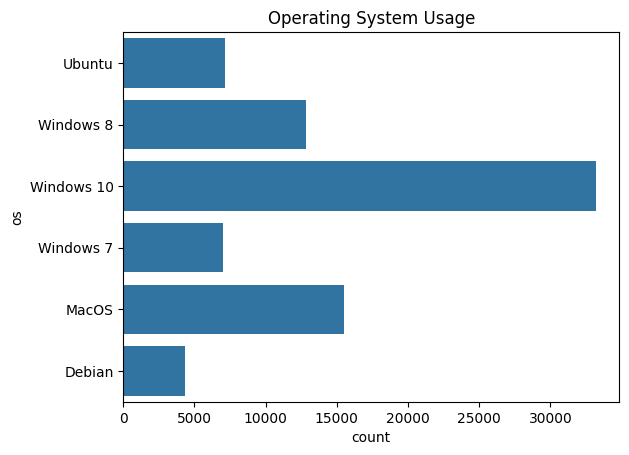

In [47]:
sns.countplot(y=df["os"])
plt.title("Operating System Usage")
plt.show()

In [48]:
df["num_sites"] = df["sites"].apply(len)

In [49]:
df["total_time"] = df["sites"].apply(
    lambda x: sum(site["length"] for site in x)
)

In [50]:
df["avg_time_per_site"] = df["total_time"] / df["num_sites"]
df["avg_time_per_site"] = df["avg_time_per_site"].fillna(0)

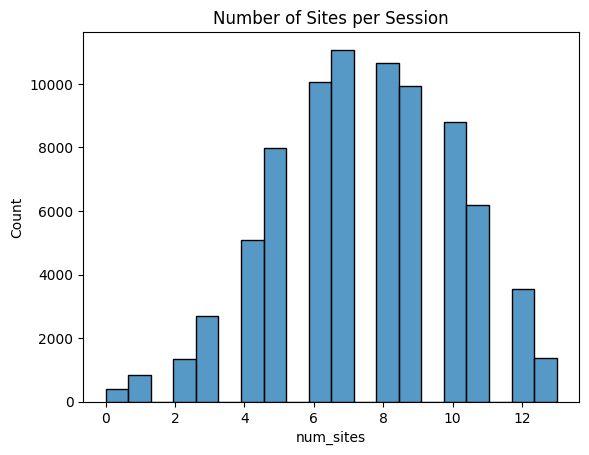

In [51]:
sns.histplot(df["num_sites"], bins=20)
plt.title("Number of Sites per Session")
plt.show()

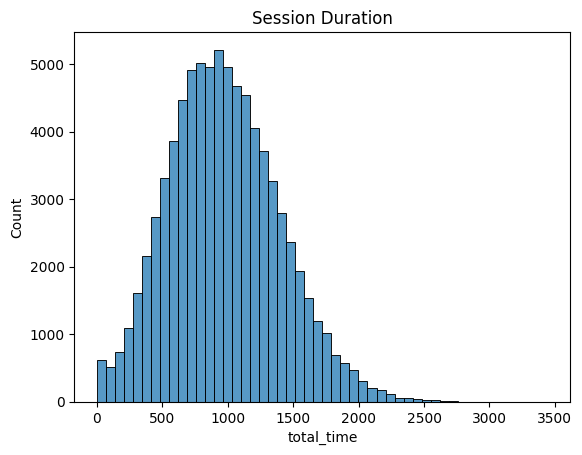

In [52]:
sns.histplot(df["total_time"], bins=50)
plt.title("Session Duration")
plt.show()

In [53]:
df["site_list"] = df["sites"].apply(
    lambda x: [s["site"] for s in x]
)

In [54]:
all_sites = []

for sites in df["site_list"]:
    all_sites.extend(sites)

site_counts = Counter(all_sites)

top_sites = [site for site,_ in site_counts.most_common(10)]
top_sites

['youtube.com',
 'toptal.com',
 'slack.com',
 'lenta.ru',
 'vk.com',
 'mail.google.com',
 'oracle.com',
 'wikimedia.org',
 'googleapis.com',
 'vimeo.com']

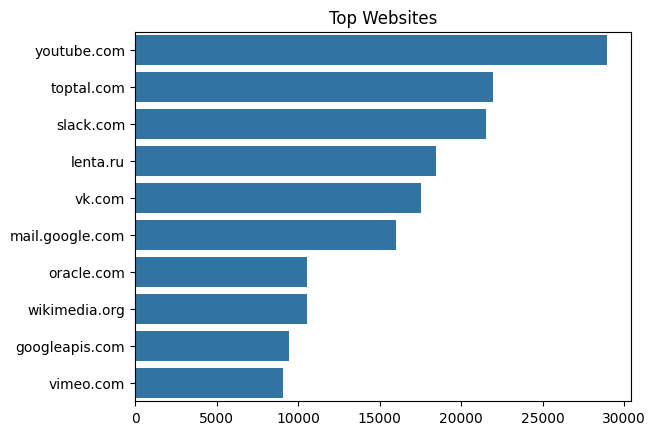

In [56]:
top_sites_counts = site_counts.most_common(10)

sites = [x[0] for x in top_sites_counts]
counts = [x[1] for x in top_sites_counts]

sns.barplot(x=counts,y=sites)
plt.title("Top Websites")
plt.show()

In [57]:
for site in top_sites:
    df[f"visit_{site}"] = df["site_list"].apply(
        lambda x: 1 if site in x else 0
    )

In [58]:
df = pd.get_dummies(
    df,
    columns=["browser","os","locale","gender","location"]
)

In [59]:
X = df.drop(columns=[
"user_id","sites","site_list","time","date","target"
])

y = df["target"]

# test train split prepare

In [60]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

## model train-->> Logistic regression

In [61]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000
)

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

# AUC-ROC score check

In [63]:
pred = model.predict_proba(X_test)[:,1]

roc_auc_score(y_test,pred)

0.9893950803212852

## Apply Feature Engineering to verify_df

In [64]:
verify_df["time"] = pd.to_datetime(verify_df["time"])
verify_df["hour"] = verify_df["time"].dt.hour

verify_df["date"] = pd.to_datetime(verify_df["date"])
verify_df["weekday"] = verify_df["date"].dt.dayofweek

verify_df["num_sites"] = verify_df["sites"].apply(len)

verify_df["total_time"] = verify_df["sites"].apply(
    lambda x: sum(site["length"] for site in x)
)

verify_df["avg_time_per_site"] = verify_df["total_time"]/verify_df["num_sites"]
verify_df["avg_time_per_site"] = verify_df["avg_time_per_site"].fillna(0)

verify_df["site_list"] = verify_df["sites"].apply(
    lambda x: [s["site"] for s in x]
)

/var/folders/n4/5mpnny3d2n5dqdtvgpbhfmdw0000gn/T/ipykernel_8294/1090900308.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  verify_df["time"] = pd.to_datetime(verify_df["time"])


In [65]:
for site in top_sites:

    verify_df[f"visit_{site}"] = verify_df["site_list"].apply(
        lambda x: 1 if site in x else 0
    )

In [66]:
verify_df = pd.get_dummies(
    verify_df,
    columns=["browser","os","locale","gender","location"]
)

In [67]:
verify_X = verify_df.reindex(columns=X.columns,fill_value=0)

In [68]:
predictions = model.predict_proba(verify_X)[:,1]

In [69]:
result = pd.DataFrame({
    "session_id": verify_df.index,
    "joe_probability": predictions
})

result.to_csv("predictions.csv",index=False)

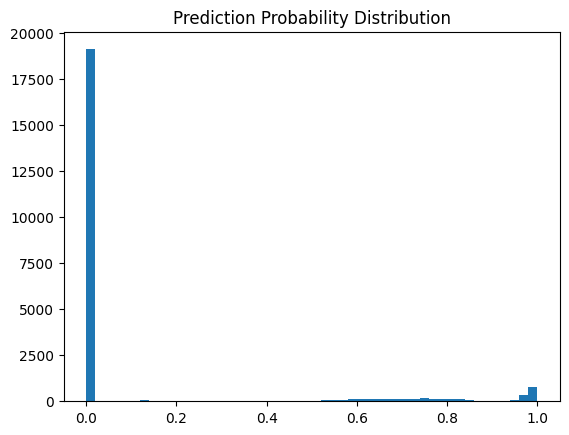

In [70]:
import matplotlib.pyplot as plt

plt.hist(predictions, bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

In [71]:
predictions.mean()

np.float64(0.12108691247333049)

In [72]:
verify_X.describe()

,hour,weekday,num_sites,total_time,avg_time_per_site,visit_youtube.com,visit_toptal.com,visit_slack.com,visit_lenta.ru,visit_vk.com,visit_mail.google.com,visit_oracle.com,visit_wikimedia.org,visit_googleapis.com,visit_vimeo.com
count,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.000000,22700.00000,22700.000000,22700.000000,22700.000000,22700.000000
mean,11.553392,2.997621,8.281322,1069.945507,129.230711,0.423084,0.361233,0.348018,0.317401,0.312907,0.30837,0.123480,0.128106,0.105991,0.097181
std,6.699810,1.999051,2.299174,393.013465,32.813084,0.494059,0.480369,0.476352,0.465475,0.463687,0.46183,0.328995,0.334215,0.307833,0.296210
min,0.000000,0.000000,3.000000,144.000000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1.000000,7.000000,782.000000,106.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,12.000000,3.000000,8.000000,1040.000000,125.261364,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,17.000000,5.000000,10.000000,1322.000000,147.900000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000
max,23.000000,6.000000,13.000000,3031.000000,353.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [73]:
(predictions > 0.5).sum()

np.int64(3292)

In [76]:
threshold = 0.5
joe_sessions = (predictions > threshold).sum()

print("Predicted Joe sessions:", joe_sessions)

Predicted Joe sessions: 3292


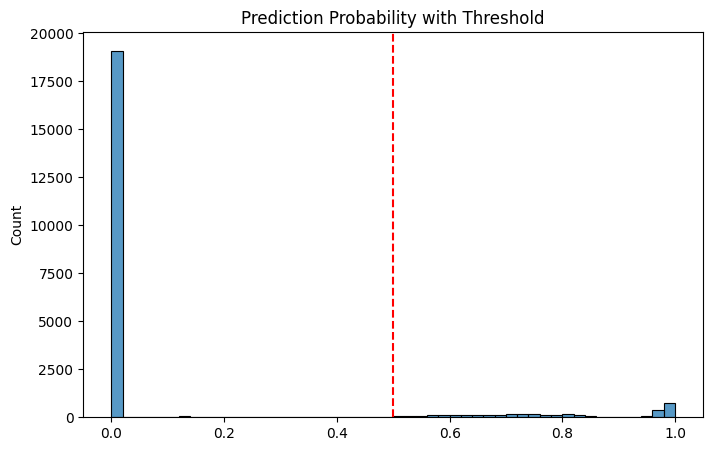

In [77]:
plt.figure(figsize=(8,5))
sns.histplot(predictions, bins=50)
plt.axvline(0.5, color="red", linestyle="--")
plt.title("Prediction Probability with Threshold")
plt.show()

In [78]:
coeff = pd.Series(model.coef_[0], index=X.columns)

top_positive = coeff.sort_values(ascending=False).head(10)
top_negative = coeff.sort_values().head(10)

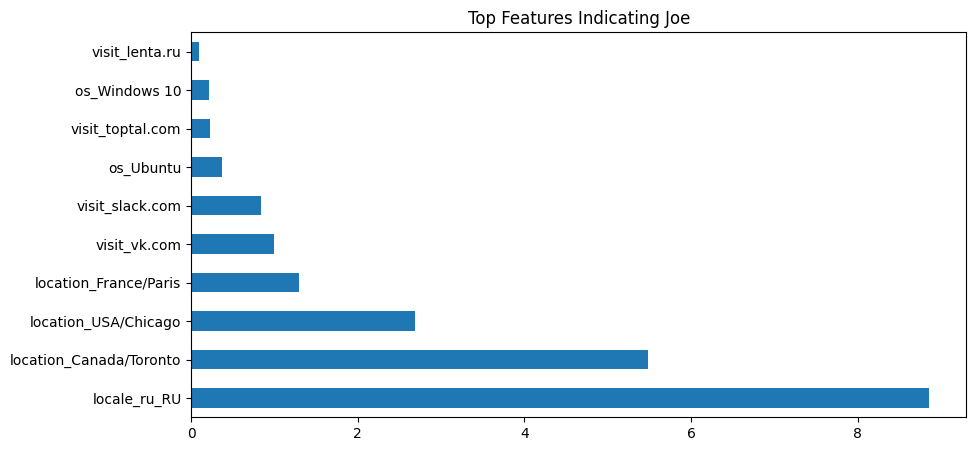

In [79]:
plt.figure(figsize=(10,5))
top_positive.plot(kind="barh")
plt.title("Top Features Indicating Joe")
plt.show()

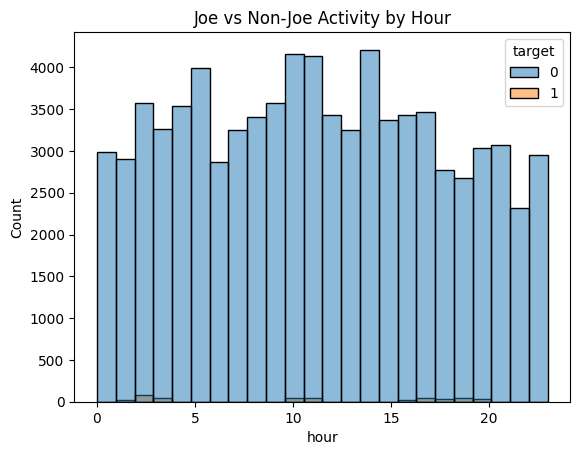

In [80]:
sns.histplot(data=df, x="hour", hue="target", bins=24)
plt.title("Joe vs Non-Joe Activity by Hour")
plt.show()

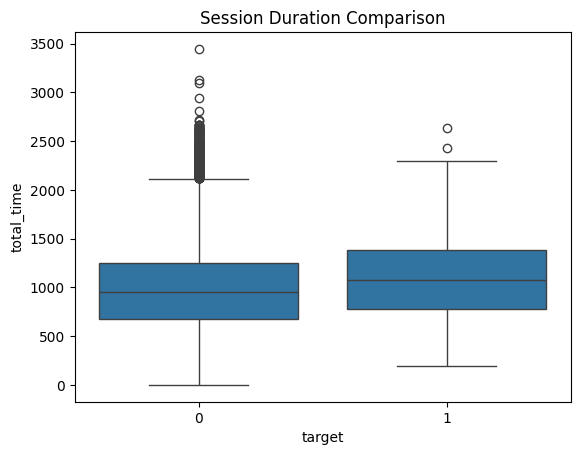

In [83]:
sns.boxplot(x="target", y="total_time", data=df)
plt.title("Session Duration Comparison")
plt.show()

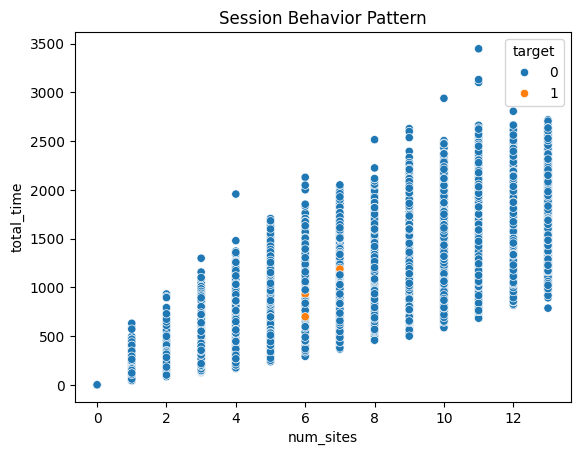

In [84]:
sns.scatterplot(
    x=df["num_sites"],
    y=df["total_time"],
    hue=df["target"]
)

plt.title("Session Behavior Pattern")
plt.show()

## check all metrices

In [85]:
pred = model.predict_proba(X_test)[:,1]

In [90]:
y_pred = (pred > 0.9).astype(int)

In [91]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9715625
Precision: 0.11591355599214145
Recall: 0.921875
F1-score: 0.20593368237347295


## ROC Curve

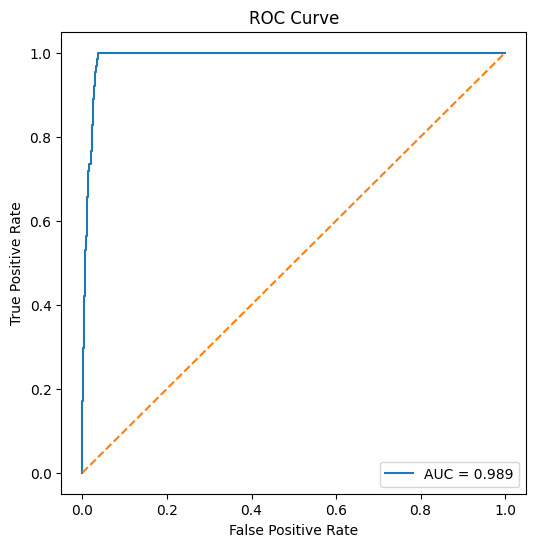

In [94]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test,pred):.3f}")
plt.plot([0,1],[0,1],'--')  # random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve

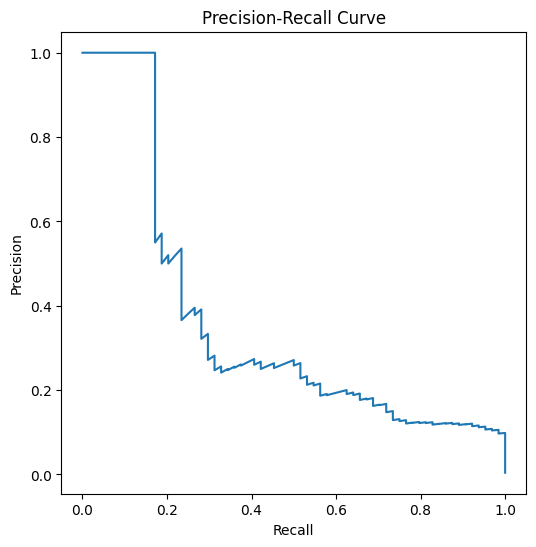

In [95]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, pred)

plt.figure(figsize=(6,6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Threshold Tuning Analysis

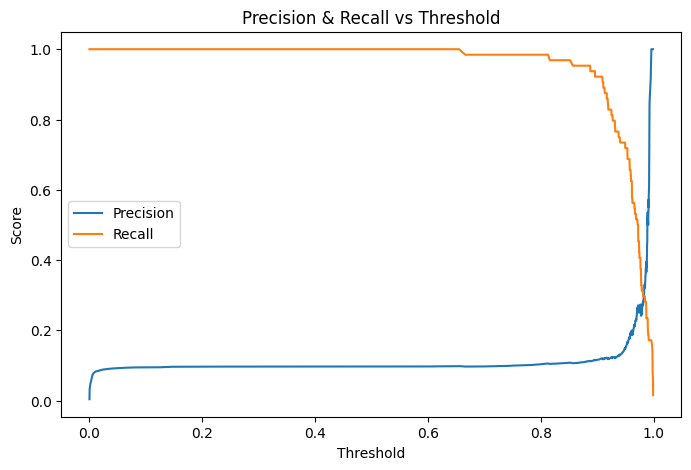

In [96]:
precision, recall, thresholds = precision_recall_curve(y_test, pred)

plt.figure(figsize=(8,5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision & Recall vs Threshold")

plt.show()

## Create Random Session Data(for testing)

In [97]:
import pandas as pd

sample_session = {
    "browser": "Chrome",
    "os": "Ubuntu",
    "locale": "zh-CN",
    "gender": "m",
    "location": "Singapore/Singapore",
    "sites": [
        {"site": "facebook.net", "length": 74},
        {"site": "live.com", "length": 246},
        {"site": "youtube.com", "length": 109},
        {"site": "baidu.com", "length": 95},
        {"site": "digitaltrends.com", "length": 74},
        {"site": "womensinfluencernetwork.com", "length": 306},
        {"site": "mozilla.com", "length": 376}
    ],
    "time": "02:06:00",
    "date": "2017-03-28"
}

sample_df = pd.DataFrame([sample_session])

 apply feature engineering on it

In [98]:
sample_df["time"] = pd.to_datetime(sample_df["time"])
sample_df["hour"] = sample_df["time"].dt.hour

sample_df["date"] = pd.to_datetime(sample_df["date"])
sample_df["weekday"] = sample_df["date"].dt.dayofweek

 session statistics

In [99]:
sample_df["num_sites"] = sample_df["sites"].apply(len)

sample_df["total_time"] = sample_df["sites"].apply(
    lambda x: sum(site["length"] for site in x)
)

sample_df["avg_time_per_site"] = sample_df["total_time"] / sample_df["num_sites"]

 extract site list

In [100]:
sample_df["site_list"] = sample_df["sites"].apply(
    lambda x: [s["site"] for s in x]
)

create visit features

In [101]:
for site in top_sites:
    sample_df[f"visit_{site}"] = sample_df["site_list"].apply(
        lambda x: 1 if site in x else 0
    )

One-Hot Encoding

In [102]:
sample_df = pd.get_dummies(
    sample_df,
    columns=["browser","os","locale","gender","location"]
)

Align Columns With Training Data

In [103]:
sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

Predict Joe Probability

In [104]:
prob = model.predict_proba(sample_df)[:,1]

print("Joe Probability:", prob[0])

Joe Probability: 2.9833461092031063e-05


Convert to Label

In [105]:
threshold = 0.9

if prob[0] > threshold:
    print("Prediction: Joe session")
else:
    print("Prediction: Not Joe")

Prediction: Not Joe
